## Data Preparation for Domestic Exports

Date Alignment: merge year and month into a single chronological date.

Handling "Other": This dataset includes a massive "Other" category. I will keep it to ensure totals match the total column, which gives a realistic view of the overall export economy.

Path Consistency: We use the BASE_DIR and CLEAN_DATA logic i defined earlier.

In [6]:
# 1. Ensure the library is loaded in the current cell
library(tidyverse)
library(scales)

# 2. Setup the dynamic path
base_dir <- "../../"
clean_data_path <- file.path(base_dir, "data", "cleaned")
domestic_file <- file.path(clean_data_path, "value_domestic_exports.csv")

# 3. Read and Transform
df_domestic_raw <- read.csv(domestic_file, stringsAsFactors = FALSE)

# Using the pipe operator safely
df_domestic <- df_domestic_raw %>%
  dplyr::mutate(date = as.Date(paste(year, month, "01", sep = "-"), format = "%Y-%B-%d")) %>%
  dplyr::arrange(date) %>%
  dplyr::select(date, coffee, tea, petroleum, chemicals, fish, horticulture, cement, other, total)

# Preview to confirm it worked
print("Data loading successful. First 5 rows:")
head(df_domestic, 5)

[1] "Data loading successful. First 5 rows:"


,date,coffee,tea,petroleum,chemicals,fish,horticulture,cement,other,total
,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1998-08-01,500.47,2404.70,850.60,695.15,183.19,854.04,117.68,3543.33,9149.16
2,1998-09-01,536.21,2564.06,848.42,606.82,204.02,1446.75,99.66,3555.47,9861.40
3,1998-10-01,584.32,2450.01,896.47,587.63,306.09,1659.82,136.22,2690.39,9310.95
4,1998-11-01,578.74,2295.48,784.25,890.20,235.66,1295.53,96.46,2457.39,8633.71
5,1998-12-01,574.54,2129.77,799.11,724.44,81.92,1491.47,111.75,3166.33,9079.32


## 1. Value Composition

We are going to visualize the Total Domestic Export Value using a Stacked Area Chart. This is the most effective way to see if non-agricultural sectors (like Chemicals or Petroleum) are growing their slice of the pie.

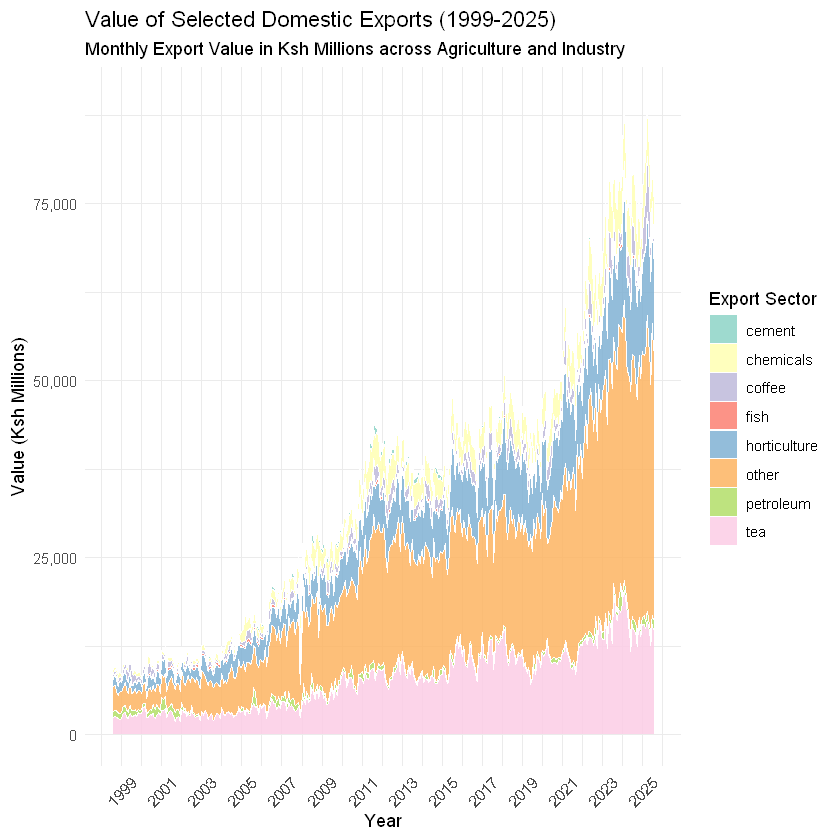

In [7]:
# 1. Reshape data for plotting
df_dom_long <- df_domestic %>%
  dplyr::select(-total) %>% # Remove total column to avoid double counting
  tidyr::pivot_longer(cols = -date, names_to = "Sector", values_to = "Value")

# 2. Plotting the Composition
ggplot(df_dom_long, aes(x = date, y = Value, fill = Sector)) +
  geom_area(alpha = 0.85, color = "white", linewidth = 0.05) +
  scale_fill_brewer(palette = "Set3") + # Using a wider color palette for more categories
  scale_y_continuous(labels = scales::label_comma()) +
  scale_x_date(date_breaks = "2 years", date_labels = "%Y") +
  labs(
    title = "Value of Selected Domestic Exports (1999-2025)",
    subtitle = "Monthly Export Value in Ksh Millions across Agriculture and Industry",
    x = "Year", y = "Value (Ksh Millions)",
    fill = "Export Sector"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 0.5))

## Observation
The 'Other' category is that large, it's often a sign of a 'Long Tail' economy—meaning Kenya isn't just a Tea and Coffee shop, but a supermarket of hundreds of smaller manufactured goods (textiles, essential oils, plastic lidded jars, scrap metal, etc.) that collectively outweigh the famous exports.

## 2. Industrial vs. Agricultural Growth (Normalized)

Since the values of Tea are huge and Cement values are smaller, they are hard to compare on one graph. We will normalize the data (Indexed to 100) starting from a specific point (e.g., the year 2010).

**The Goal:** To see which sector has grown the fastest in percentage terms, regardless of its starting size.

This identifies the Emerging Stars of the Kenyan economy.

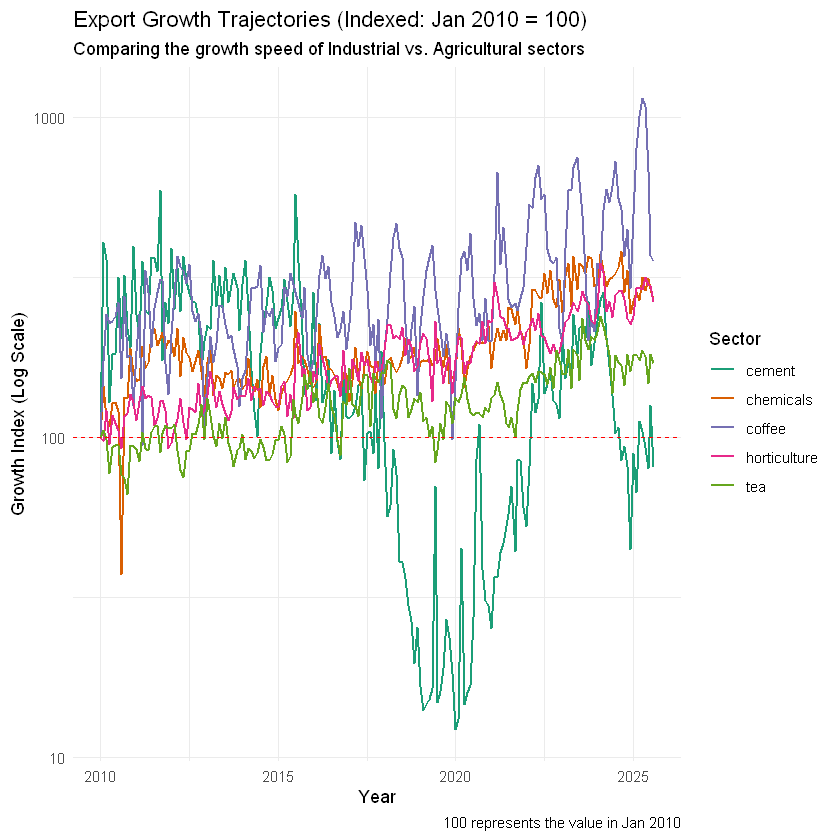

In [21]:
# 1. Filtering using the 'date' column and indexing to 100
df_growth <- df_domestic %>%
  # Filter by date since 'year' was dropped in the previous select
  dplyr::filter(date >= as.Date("2010-01-01")) %>%
  # Normalize every column so the first value (Jan 2010) is 100
  dplyr::mutate(across(c(coffee, tea, chemicals, cement, horticulture), 
                ~ (. / dplyr::first(.)) * 100)) %>%
  dplyr::select(date, coffee, tea, chemicals, cement, horticulture) %>%
  tidyr::pivot_longer(cols = -date, names_to = "Sector", values_to = "Index_100")

# 2. Plotting the Growth Trajectories
ggplot(df_growth, aes(x = date, y = Index_100, color = Sector)) +
  geom_line(linewidth = 0.8) +
  geom_hline(yintercept = 100, linetype = "dashed", color = "red") +
  # Using log scale to better visualize relative percentage changes
  scale_y_log10() + 
  scale_color_brewer(palette = "Dark2") +
  labs(
    title = "Export Growth Trajectories (Indexed: Jan 2010 = 100)",
    subtitle = "Comparing the growth speed of Industrial vs. Agricultural sectors",
    x = "Year", y = "Growth Index (Log Scale)",
    caption = "100 represents the value in Jan 2010"
  ) +
  theme_minimal()

## 3. The 'Other' Sector Structural Trend

Because the "Other" category is the largest part of the dataset, we need to know if its growth is stable. We use a 12-month rolling average (using the zoo library) to cut through the "noise" of monthly fluctuations and see the long-term structural trend of Kenya's diversified exports.

Warning message:
"Removed 11 rows containing missing values or values outside the scale range
(`geom_line()`)."


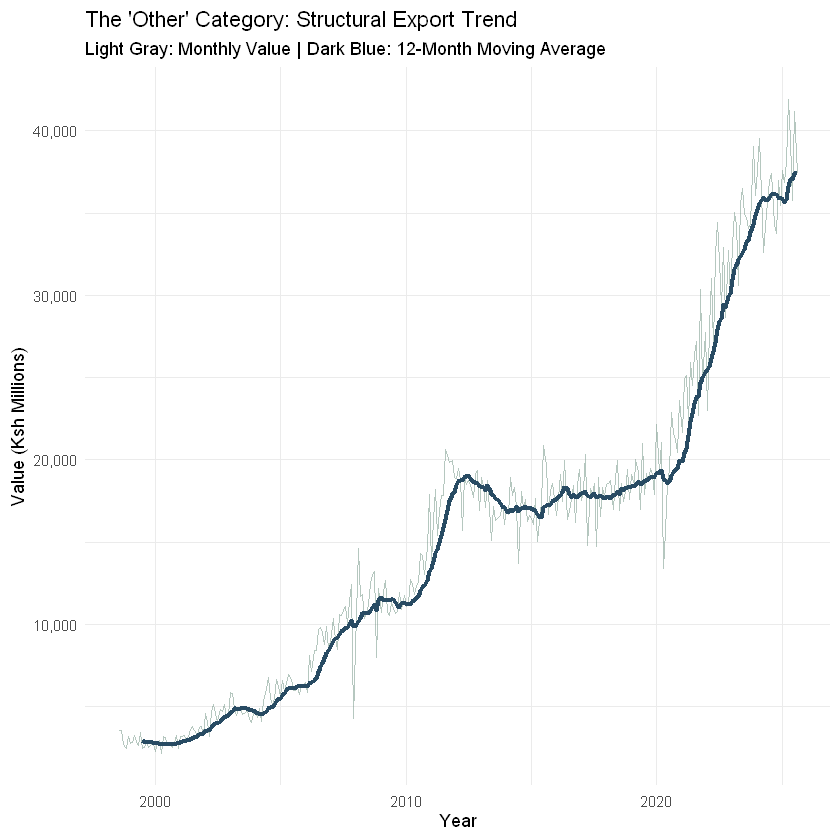

In [26]:
library(zoo) # Ensure zoo is loaded for the rolling mean function

# 1. Calculate 12-month moving average for 'Other'
df_domestic_trends <- df_domestic %>%
  dplyr::mutate(other_smooth = zoo::rollmean(other, k = 12, fill = NA, align = "right"))

# 2. Plot the Trend
ggplot(df_domestic_trends, aes(x = date)) +
  # Raw monthly data in light gray
  geom_line(aes(y = other), color = "#6b9080", alpha = 0.5) + 
  # Smoothed 12-month trend in dark professional blue
  geom_line(aes(y = other_smooth), color = "#284b63", linewidth = 1.2) + 
  scale_y_continuous(labels = scales::label_comma()) +
  labs(
    title = "The 'Other' Category: Structural Export Trend",
    subtitle = "Light Gray: Monthly Value | Dark Blue: 12-Month Moving Average",
    x = "Year", y = "Value (Ksh Millions)"
  ) +
  theme_minimal()